<a href="https://colab.research.google.com/github/janani26121992/AI-Projects/blob/main/CIFAR_Image_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***CIFAR Image Prediction Model***

In [ ]:
from keras.datasets import cifar10
(xtrain,ytrain),(xtest,ytest) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
xtrain.shape

(50000, 32, 32, 3)

In [ ]:
ytrain.shape

(50000, 1)

In [ ]:
ytrain[0]

array([6], dtype=uint8)

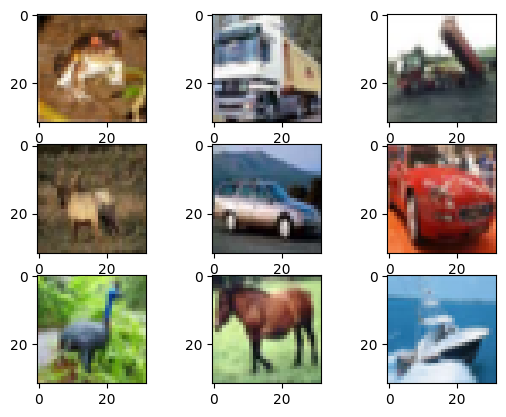

In [ ]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(3,3)
k=0
for i in range(3):
  for j in range(3):
    axs[i][j].imshow(xtrain[k])
    k+=1

# ***Scaling of X and Y***

In [ ]:
#X scaling
xtrain_scl = xtrain.astype("float32")/255
xtest_scl = xtest.astype("float32")/255

In [ ]:
#y scaling
from keras.utils import to_categorical
ytrain_scl = to_categorical(ytrain)
ytest_scl = to_categorical(ytest)

In [ ]:
ytrain_scl.shape

(50000, 10)

10 classes are there for this dataset

airplane

automobile

bird

cat

deer

dog

frog

horse

ship
truck

# ***Model Building***

In [ ]:
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPool2D,Flatten,BatchNormalization,Dropout
from keras.callbacks import EarlyStopping

In [ ]:
# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(32,32,3),))

# Add the Convolution layer, Maxpooling layer
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Add another Convolution layer, Maxpooling layer
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Add the Flatten layer - convert ndarray into 1d array
model.add(Flatten())

# Add the Hidden layer
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add the output layer
model.add(Dense(ytrain_scl.shape[1],activation='softmax'))

In [ ]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss',patience=15)

In [ ]:
nn= model.fit(xtrain_scl,ytrain_scl,validation_split=0.2,epochs=100,callbacks=[es])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 53ms/step - accuracy: 0.5170 - loss: 1.4003 - val_accuracy: 0.6110 - val_loss: 1.1051
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.6436 - loss: 1.0217 - val_accuracy: 0.5862 - val_loss: 1.2059
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.6931 - loss: 0.8845 - val_accuracy: 0.6060 - val_loss: 1.1410
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 49ms/step - accuracy: 0.7264 - loss: 0.7913 - val_accuracy: 0.6877 - val_loss: 0.9109
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.7523 - loss: 0.7163 - val_accuracy: 0.6327 - val_loss: 1.2329
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 0.7723 - loss: 0.6625 - val_accuracy: 0.7086 - val_loss: 0.8697
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.7879 - loss: 0.6136 - val_accuracy: 0.7061 - val_loss: 0.8868
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 

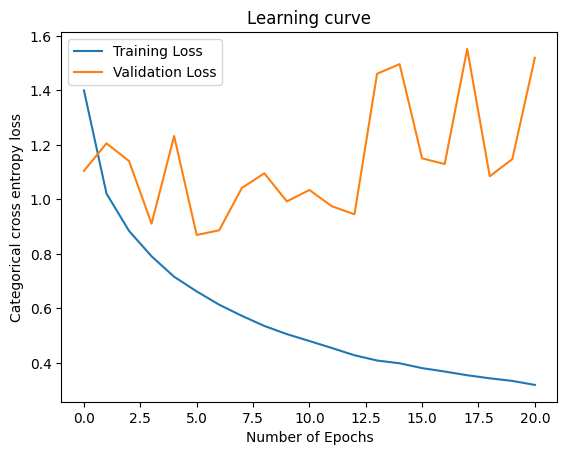

In [ ]:
plt.plot(nn.history['loss'],label="Training Loss")
plt.plot(nn.history['val_loss'],label="Validation Loss")
plt.title("Learning curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Categorical cross entropy loss")
plt.legend()
plt.show()